In [5]:
%run dataPreprocessing.ipynb


Net_Metrekare             0
Brüt_Metrekare            0
Oda_Sayısı              260
Bulunduğu_Kat          2297
Eşya_Durumu            7398
Binanın_Yaşı              0
Isıtma_Tipi               0
Fiyat                     0
Şehir                     0
Binanın_Kat_Sayısı        0
Kullanım_Durumu           0
Yatırıma_Uygunluk      5576
Takas                  5895
Tapu_Durumu           10566
Banyo_Sayısı             46
dtype: int64


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17538 entries, 0 to 20322
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Net_Metrekare       17538 non-null  int64  
 1   Brüt_Metrekare      17538 non-null  float64
 2   Oda_Sayısı          17538 non-null  float64
 3   Bulunduğu_Kat       17538 non-null  object 
 4   Binanın_Yaşı        17538 non-null  object 
 5   Isıtma_Tipi         17538 non-null  object 
 6   Fiyat               17538 non-null  float64
 7   Şehir               17538 non-null  object 
 8   Binanın_Kat_Sayısı  17538 non-null  int64  
 9   Kullanım_Durumu     17538 non-null  object 
 10  Banyo_Sayısı        17538 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 1.6+ MB


## Model oluşturmaya hazırlık

Veri setimiziden hedef sütunu ayırma

In [8]:
x = data.drop("Fiyat",axis=1)
y = data["Fiyat"]


Kategorik verileri encode etme

In [9]:
kategorik_veri = x.select_dtypes(include=["object"]).columns
x = pd.get_dummies(x,columns=kategorik_veri,drop_first=True)

x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17538 entries, 0 to 20322
Columns: 115 entries, Net_Metrekare to Kullanım_Durumu_Mülk Sahibi Oturuyor
dtypes: bool(110), float64(3), int64(2)
memory usage: 2.6 MB


Eğitim ve Test verisi olarak ayırma

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33,random_state=42)

Ölçeklendirme 

Scaling önemli olan modeller:

    Linear Regression

    SVR

    KNN

    Logistic Regression

Scaling gerekmeyen modeller:

    Decision Tree

    Random Forest

    XGBoost

In [11]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Model oluşturma

Kütüphaneler

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


## Model Seçme

### Metrik anlamları:
##### 1. MAE (Ortalama Mutlak Hata)

###### Detay: Tahminlerin ile gerçek değerler arasındaki farkların basit ortalamasıdır. Hataların negatif veya pozitif olması fark etmez.

###### Örnek: Bir araba fiyatı tahmin modelinde MAE değerin 10.000 ise, modelin arabaların fiyatını ortalama 10.000 TL eksik veya fazla tahmin ediyor demektir.

##### 2. RMSE (Kök Ortalama Kare Hata)

###### Detay: Hataların önce karesi alınıp sonra ortalamasının karekökü bulunduğu için, modelin yaptığı büyük hatalara karşı çok daha hassastır ve bunları yüksek skorla cezalandırır.

###### Örnek: 100 arabanın fiyatını 1.000 TL hatayla, 1 arabanın fiyatını ise 500.000 TL hatayla tahmin edersen; MAE bu durumu pek umursamaz ama RMSE o tek büyük hata yüzünden anında fırlar. Modelin tutarsızlıklarını görmek için harikadır.

##### 3. R² (R-Kare / Modelin Açıklama Gücü)

###### Detay: Genellikle 0 ile 1 arasında değer alır. Elindeki girdilerin (özelliklerin), tahmin etmeye çalıştığın hedefteki değişimi yüzde kaç oranında açıklayabildiğini gösterir. 1'e ne kadar yakınsa model o kadar başarılıdır.

###### Örnek: R² skorun 0.85 ise, araba fiyatlarındaki değişikliğin %85'ini modelindeki verilerle (kilometre, yıl, hasar durumu vb.) doğru bir şekilde yakalayabiliyorsun demektir.

In [13]:
models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "SVR" : SVR(),
    "GradientBoostingRegressor" : GradientBoostingRegressor(),
    "XGBRegressor" : XGBRegressor()

}

results = []

for name, model in models.items():

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)

    results.append([
    name,
    round(r2,2),
    round(mae/1000,0),
    round(rmse/1000000,2)
])

    print(f"{name} R2: {r2:.2f}")
    print(f"{name} MAE: {mae/1000:.0f}k")
    print(f"{name} RMSE: {rmse/1000000:.2f}M")


results_df = pd.DataFrame(results, columns=["Model","R2","MAE","RMSE"])

results_df

   

Linear R2: 0.12
Linear MAE: 701k
Linear RMSE: 1.52M
DecisionTree R2: 0.18
DecisionTree MAE: 807k
DecisionTree RMSE: 1.47M
RandomForest R2: 0.54
RandomForest MAE: 615k
RandomForest RMSE: 1.10M
SVR R2: -0.04
SVR MAE: 997k
SVR RMSE: 1.66M
GradientBoostingRegressor R2: 0.52
GradientBoostingRegressor MAE: 661k
GradientBoostingRegressor RMSE: 1.13M
XGBRegressor R2: 0.53
XGBRegressor MAE: 604k
XGBRegressor RMSE: 1.11M


,Model,R2,MAE,RMSE
0,Linear,0.12,701.0,1.52
1,DecisionTree,0.18,807.0,1.47
2,RandomForest,0.54,615.0,1.10
3,SVR,-0.04,997.0,1.66
4,GradientBoostingRegressor,0.52,661.0,1.13
5,XGBRegressor,0.53,604.0,1.11


# EN İYİ MODEL RandomForest


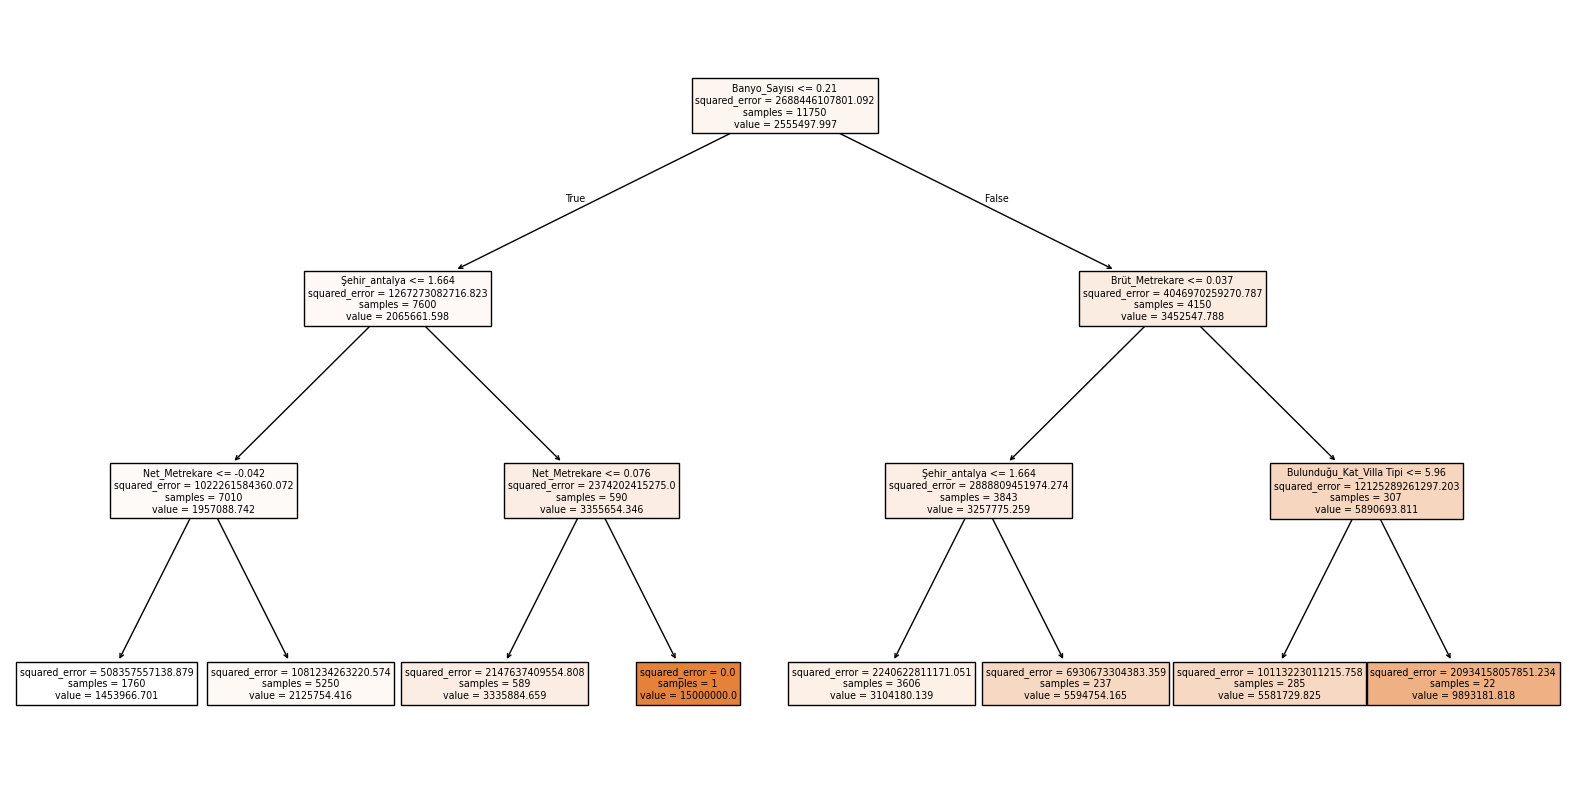

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

import pandas as pd

data_tree = pd.read_csv("home_price.csv")


model = DecisionTreeRegressor(max_depth=3)
model.fit(x_train, y_train)


plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=x.columns,
    filled=True
)

plt.show()
plt.show()